In [32]:
# ==========================================
# Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader


In [33]:
# ==========================================
# 1.Load the data set
# ==========================================
df = pd.read_csv("C:/Users/muhda/Desktop/PG/2ND/dataset/LT.csv")

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                4184 non-null   str    
 1   Symbol              4184 non-null   str    
 2   Series              4184 non-null   str    
 3   Prev Close          4184 non-null   float64
 4   Open                4184 non-null   float64
 5   High                4184 non-null   float64
 6   Low                 4184 non-null   float64
 7   Last                4184 non-null   float64
 8   Close               4184 non-null   float64
 9   VWAP                4184 non-null   float64
 10  Volume              4184 non-null   int64  
 11  Turnover            4184 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4184 non-null   int64  
 14  %Deliverble         4184 non-null   float64
dtypes: float64(10), int64(2), str(3)
memory usage: 547.6 KB


In [35]:
#fix date , sorting and cleaning
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.drop_duplicates().dropna()

# selecting needed columns
cols = ['Prev Close','Open','High','Low','Last','Close',
        'VWAP', 'Volume','Turnover','Trades','Deliverable Volume']
data =df[cols].values
dates =df['Date'].values

In [36]:
# ==========================================
# 2. Train/Test Split & Normalization
# ==========================================
split=int(len(data) * 0.8)
train_dt=data[:split]
test_dt=data[split:]

scaler=StandardScaler()
train_scaled=scaler.fit_transform(train_dt)
test_scaled=scaler.transform(test_dt)
scaled_data=np.vstack((train_scaled,test_scaled))

In [37]:
# ==========================================
# 3.Time-Series Chunking
# ==========================================
X,y,target_dates=[],[],[]
for i in range(len(scaled_data)-20-5+1):
    X.append(scaled_data[i:i+20])
    y.append(scaled_data[i+20:i+20+5])
    target_dates.append(dates[i+20:i+20+5])

X=np.array(X)
y=np.array(y)

# split again
seq_split=int(len(X)*0.8)
X_train,X_test=X[:seq_split],X[seq_split:]
y_train,y_test=y[:seq_split],y[seq_split:]
dates_test=target_dates[seq_split:]

#loaders
train_loader=DataLoader(TensorDataset(torch.FloatTensor(X_train),torch.FloatTensor(y_train)),batch_size=32,shuffle=False)
test_loader=DataLoader(TensorDataset(torch.FloatTensor(X_test),torch.FloatTensor(y_test)),batch_size=32,shuffle=False)

In [38]:
# ==========================================
# 4. Defining LSTM Model
# ==========================================
class TimeSeriesLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # 11 features in , 128 hidden size, 2 layers
        self.lstm=nn.LSTM(11,128,2,batch_first=True,dropout=0.3)
        #Output gives 5 days x 11 features
        self.fc=nn.Linear(128,55) 
        
    def forward(self,x):
        out, _=self.lstm(x)
        # Take the last time step output
        out=self.fc(out[:,-1,:])  
        # Reshape output to 5 days and 11 features
        return out.view(-1,5,11) 

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=TimeSeriesLSTM().to(device) 
optimizer=torch.optim.Adam(model.parameters(),lr=0.0005)
loss_fn=nn.MSELoss()

In [39]:
# ==========================================
# 5. Training Loop
# ==========================================
for epoch in range(60):
    model.train()
    for batch_X,batch_y in train_loader:
        batch_X,batch_y=batch_X.to(device),batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()    
    if epoch % 10==0:
        print(f"Epoch {epoch} finished. Loss: {loss.item():.4f} ")

Epoch 0 finished. Loss: 0.1606 
Epoch 10 finished. Loss: 0.1458 
Epoch 20 finished. Loss: 0.1493 
Epoch 30 finished. Loss: 0.1513 
Epoch 40 finished. Loss: 0.1446 
Epoch 50 finished. Loss: 0.1386 


In [40]:
# ==========================================
# 6.Evaluation and Metrics
# ==========================================
model.eval()
test_preds=[]
test_actuals=[]

with torch.no_grad():
    for batch_X,batch_y in test_loader:
        preds = model(batch_X.to(device)).cpu().numpy()
        test_preds.append(preds)
        test_actuals.append(batch_y.numpy())

# combine all batches
test_preds =np.concatenate(test_preds,axis=0)
test_actuals =np.concatenate(test_actuals,axis=0)
# reshape to (-1, 11) for inverse scaling
test_preds =test_preds.reshape(-1,11)
test_actuals =test_actuals.reshape(-1,11)
# inverse transform (back to original values)
inv_preds =scaler.inverse_transform(test_preds)
inv_actuals =scaler.inverse_transform(test_actuals)

feature_names=['Prev Close','Open','High','Low','Last','Close','VWAP'
               ,'Volume','Turnover','Trades','Deliverable Volume']
print("\n--- Overall Model Performance ---")
overall_mse=mean_squared_error(inv_actuals,inv_preds)
overall_rmse=np.sqrt(overall_mse)
overall_mae=mean_absolute_error(inv_actuals,inv_preds)
overall_mape=np.mean(np.abs((inv_actuals - inv_preds)/(inv_actuals+1e-8)))*100
overall_accuracy = 100 - overall_mape
print(f"Overall MSE: {overall_mse:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")
print(f"Overall MAE: {overall_mae:.4f}")
print(f"Overall MAPE: {overall_mape:.2f}%")
print(f"Overall Accuracy: {overall_accuracy:.2f}%")

print("\n--- Performance Metrics(All Features) ---") 
for i in range(11):
    true_vals=inv_actuals[:, i]
    pred_vals=inv_preds[:, i]
    mse=mean_squared_error(true_vals, pred_vals)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(true_vals,pred_vals)
    mape=np.mean(np.abs((true_vals-pred_vals)/(true_vals+1e-8)))*100
    accuracy=100 - mape
    print(f"\nFeature: {feature_names[i]}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")


--- Overall Model Performance ---
Overall MSE: 11471608077935563675449425920.0000
Overall RMSE: 107105593121627.2344
Overall MAE: 21474756788224.0000
Overall MAPE: 17.45%
Overall Accuracy: 82.55%

--- Performance Metrics(All Features) ---

Feature: Prev Close
MSE: 3944.8730
RMSE: 62.8082
MAE: 45.9558
MAPE: 4.35%
Accuracy: 95.65%

Feature: Open
MSE: 4131.6758
RMSE: 64.2781
MAE: 47.5710
MAPE: 4.45%
Accuracy: 95.55%

Feature: High
MSE: 4308.4839
RMSE: 65.6390
MAE: 48.7170
MAPE: 4.46%
Accuracy: 95.54%

Feature: Low
MSE: 4426.0503
RMSE: 66.5286
MAE: 48.0311
MAPE: 4.63%
Accuracy: 95.37%

Feature: Last
MSE: 4517.8403
RMSE: 67.2149
MAE: 49.7183
MAPE: 4.64%
Accuracy: 95.36%

Feature: Close
MSE: 4492.9341
RMSE: 67.0294
MAE: 49.7571
MAPE: 4.66%
Accuracy: 95.34%

Feature: VWAP
MSE: 4473.4907
RMSE: 66.8842
MAE: 50.1218
MAPE: 4.68%
Accuracy: 95.32%

Feature: Volume
MSE: 10393443368960.0000
RMSE: 3223886.3766
MAE: 2150654.7500
MAPE: 41.92%
Accuracy: 58.08%

Feature: Turnover
MSE: 1261877903881705821

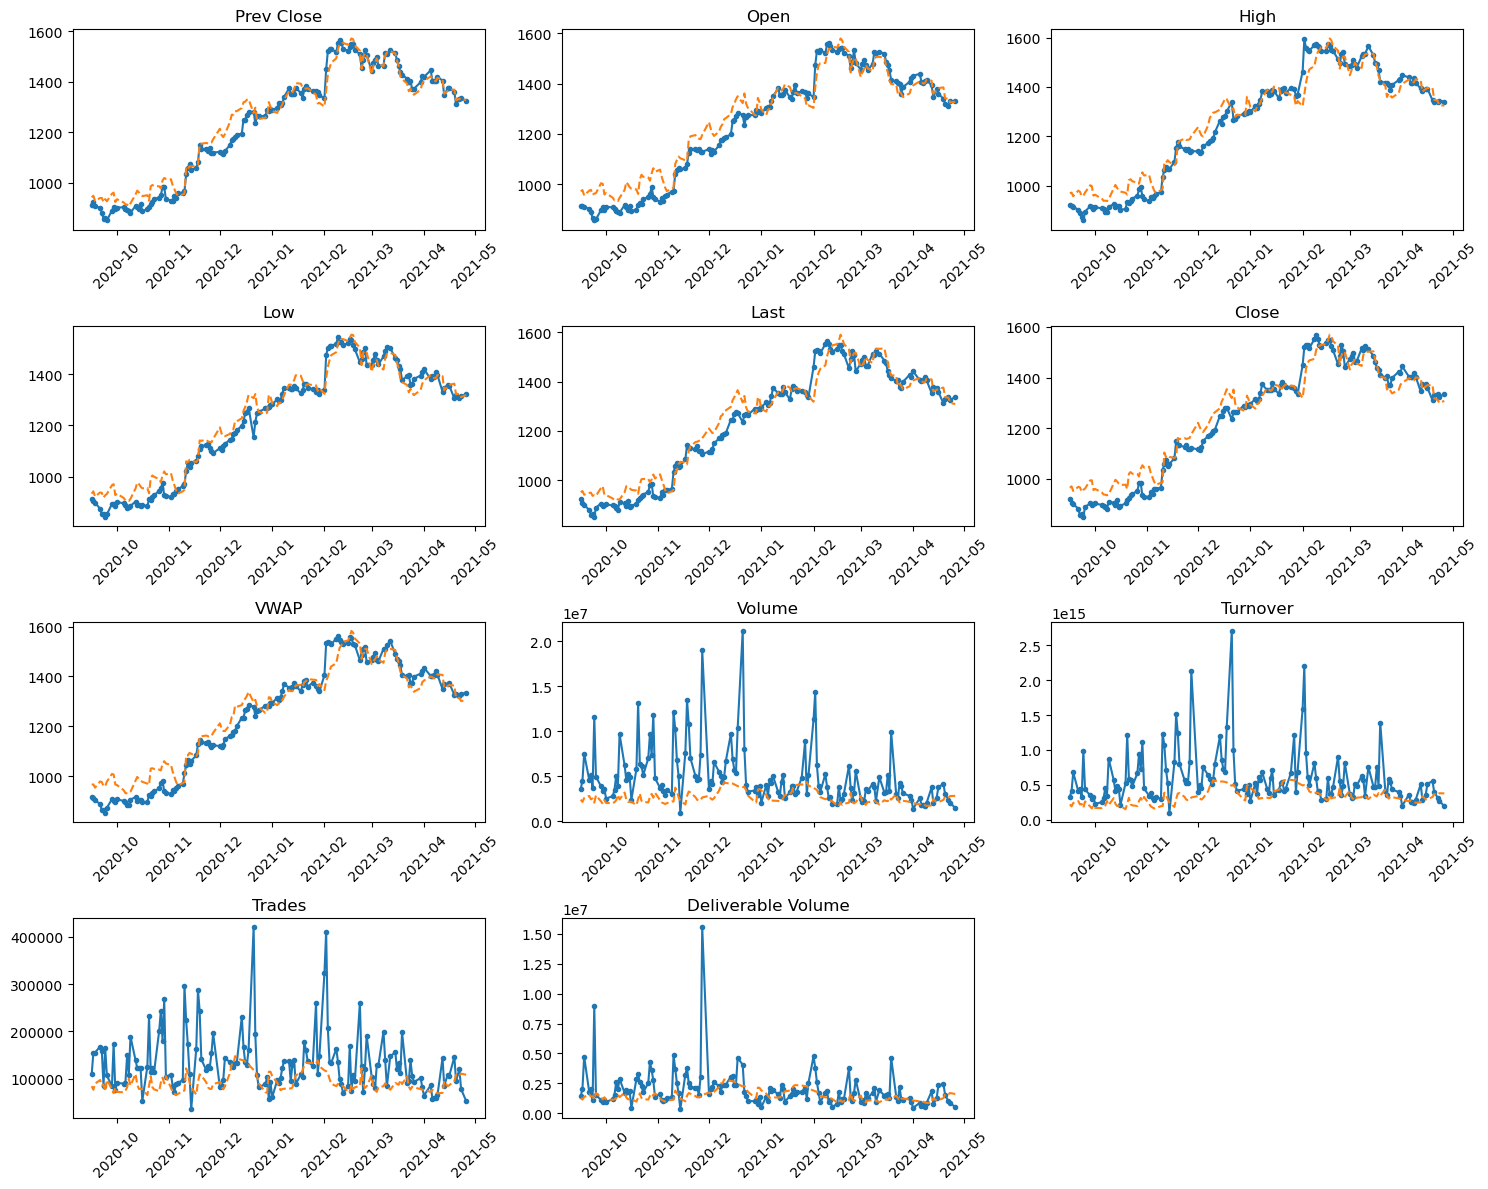

In [41]:
# ==========================================
# 7. Plotting True vs Predicted
# ==========================================
# reshape back to sequence form
inv_preds_seq=inv_preds.reshape(-1,5,11)
inv_actuals_seq=inv_actuals.reshape(-1,5,11)
plot_dates = np.array(dates_test)[:, 0]
# create 11 subplots (4 rows x 3 columns = 12 slots)
fig,axes=plt.subplots(4,3,figsize=(15,12))
axes=axes.flatten()
for i in range(11):
    true_vals=inv_actuals_seq[:,0,i]
    pred_vals=inv_preds_seq[:,0,i]
    axes[i].plot(plot_dates[-150:],true_vals[-150:],label="True",marker='.')
    axes[i].plot(plot_dates[-150:],pred_vals[-150:],label="Predicted",linestyle='--')
    axes[i].set_title(feature_names[i])
    axes[i].tick_params(axis='x',rotation=45)
# remove extra empty subplot (12th box)
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

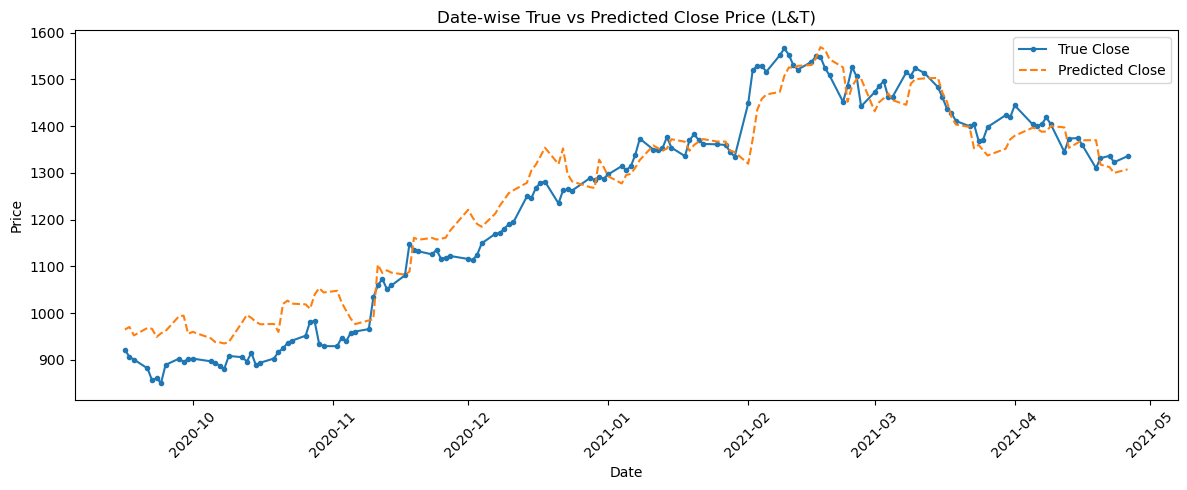

In [42]:
# ==========================================
# Close Price plot
# ==========================================
# reshape back
inv_preds_seq=inv_preds.reshape(-1,5,11)
inv_actuals_seq=inv_actuals.reshape(-1,5,11)

# take first predicted day
true_close=inv_actuals_seq[:,0,5]
pred_close=inv_preds_seq[:,0,5]

# get corresponding dates
plot_dates=np.array(dates_test)[:,0]

plt.figure(figsize=(12,5))

plt.plot(plot_dates[-150:],true_close[-150:],label="True Close",marker='.')
plt.plot(plot_dates[-150:],pred_close[-150:],label="Predicted Close",linestyle='--')

plt.title("Date-wise True vs Predicted Close Price (L&T)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()